## Global Imports & File Initialization

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score
)

from statsmodels.tsa.stattools import adfuller

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Initializing Portfolio Data Matrices")
raw_df = pd.read_csv("../data/raw/raw_prices_cache.csv", index_col=0, parse_dates=True)
scaled_X = pd.read_csv("../data/processed/stationary_scaled_features.csv", index_col=0, parse_dates=True)
print(f"  └─ Raw Price Path Matrix  : {raw_df.shape[0]} Timesteps x {raw_df.shape[1]} Assets")
print(f"  └─ Feature Signal Matrix X : {scaled_X.shape[0]} Timesteps x {scaled_X.shape[1]} Assets")

Initializing Portfolio Data Matrices
  └─ Raw Price Path Matrix  : 802 Timesteps x 5 Assets
  └─ Feature Signal Matrix X : 801 Timesteps x 5 Assets


## Distribution Uniformity Audit
**Goal:** Verify the Magnitude Scale Bias has been completely eliminated. We will plot the KDE of all 5 assets on top of each other

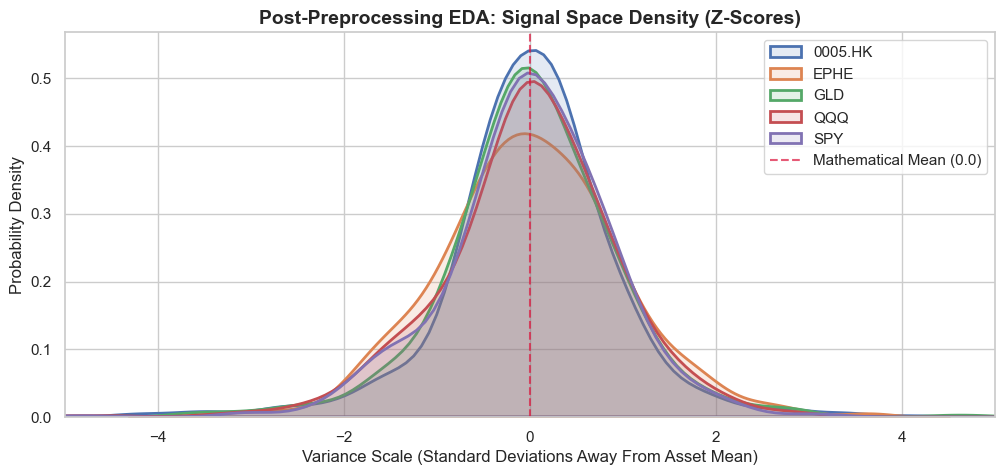

In [2]:
plt.figure(figsize=(12, 5))

for asset in scaled_X.columns:
    sns.kdeplot(data=scaled_X[asset], label=asset, fill=True, alpha=0.15, linewidth=2)

plt.axvline(x=0.0, color='crimson', linestyle='--', alpha=0.7, label='Mathematical Mean (0.0)')
plt.title("Post-Preprocessing EDA: Signal Space Density (Z-Scores)", fontsize=14, fontweight='bold')
plt.xlabel("Variance Scale (Standard Deviations Away From Asset Mean)")
plt.ylabel("Probability Density")
plt.xlim(-5, 5) 
plt.legend(loc="upper right")
plt.show()

## Stationary Signal Path Analysis
**Goal:** To check if the data already have a constant energetic pulse wave, that simply tells that the input features are offficially in weak form stationary

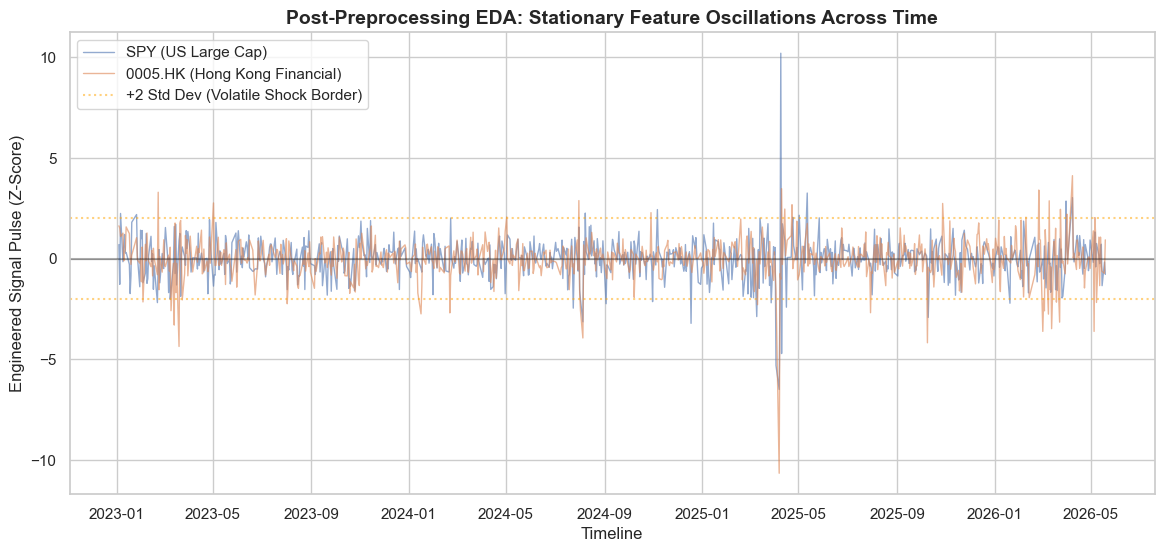

In [3]:
plt.figure(figsize=(14, 6))

plt.plot(scaled_X.index, scaled_X['SPY'], label='SPY (US Large Cap)', alpha=0.6, linewidth=1)
plt.plot(scaled_X.index, scaled_X['0005.HK'], label='0005.HK (Hong Kong Financial)', alpha=0.6, linewidth=1)

plt.axhline(y=0.0, color='black', alpha=0.3, linestyle='-')
plt.axhline(y=2.0, color='orange', alpha=0.5, linestyle=':', label='+2 Std Dev (Volatile Shock Border)')
plt.axhline(y=-2.0, color='orange', alpha=0.5, linestyle=':')

plt.title("Post-Preprocessing EDA: Stationary Feature Oscillations Across Time", fontsize=14, fontweight='bold')
plt.ylabel("Engineered Signal Pulse (Z-Score)")
plt.xlabel("Timeline")
plt.legend(loc="upper left")
plt.show()

## True Linear Dependency Heatmap
**Goal:** To evaluate asset correlation by using stationary matrix X. I remove the historical trend bias and uncover raw, true operational relationship between global assets

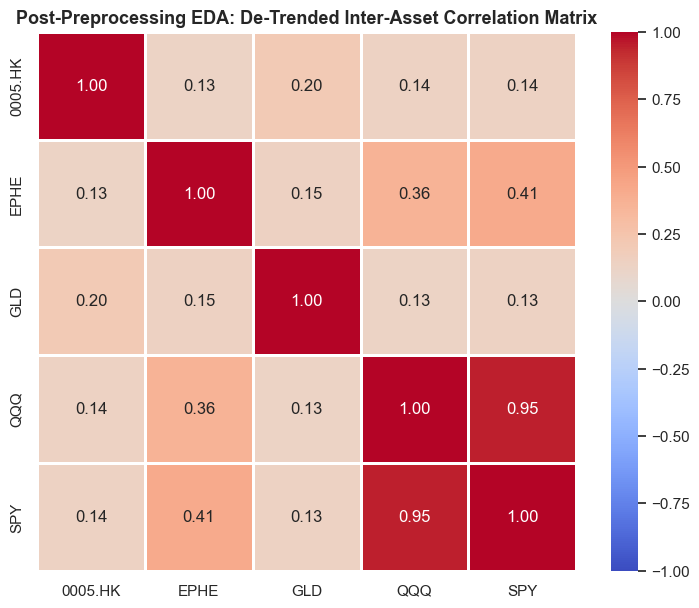

In [4]:
plt.figure(figsize=(9, 7))
stationary_corr = scaled_X.corr(method='pearson')

sns.heatmap(
    stationary_corr, 
    annot=True, 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    fmt=".2f", 
    linewidths=0.8,
    square=True
)

plt.title("Post-Preprocessing EDA: De-Trended Inter-Asset Correlation Matrix", fontsize=13, fontweight='bold')
plt.show()

## Asset Descriptive Statistics & Pearson Correlation Matrix 
**Goal:** Calculates summary bounds and visualized the underlying co-movements across global asset universe 

,count,mean,std,min,50%,max
0005.HK,801.0,-4.435348e-18,1.000625,-10.655575,0.016247,4.125825
EPHE,801.0,2.217674e-18,1.000625,-3.524209,0.003180,3.714359
GLD,801.0,-3.104744e-17,1.000625,-8.689847,0.002014,4.804965
QQQ,801.0,-4.435348e-18,1.000625,-4.982166,0.018123,8.872872
SPY,801.0,-8.870696e-18,1.000625,-6.493566,0.022803,10.206407


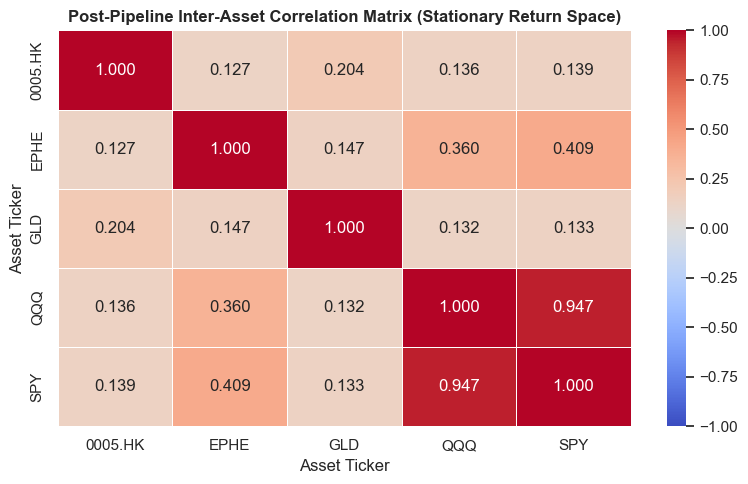

In [5]:
eda_summary = scaled_X.describe().T
display(eda_summary[['count', 'mean', 'std', 'min', '50%', 'max']])

plt.figure(figsize=(8, 5))
correlation_matrix = scaled_X.corr(method='pearson')

sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".3f", 
    linewidths=0.5, 
    vmin=-1, vmax=1
)
plt.title("Post-Pipeline Inter-Asset Correlation Matrix (Stationary Return Space)", weight='bold')
plt.ylabel("Asset Ticker")
plt.xlabel("Asset Ticker")
plt.tight_layout()
plt.show()


## ADF Test Loop 
**Goal:** Generates the core academic proof that my preprocessing successfully stabilized the data

In [7]:
print("Executing Augmented Dickey-Fuller (ADF) Tests across Feature Matrix X.")
print("=" * 65)
print(f"{'Ticker':<10} | {'ADF Statistic':<15} | {'p-value':<12} | {'Stationarity Status'}")
print("=" * 65)

for column in scaled_X.columns:
    result = adfuller(scaled_X[column].dropna())
    ticker = column
    adf_stat = result[0]
    p_value = result[1]
    
    status = "STATIONARY (Reject H0)" if p_value < 0.05 else "NON-STATIONARY (Fail to Reject)"
    print(f"{ticker:<10} | {adf_stat:<15.4f} | {p_value:<12.4e} | {status}")

print("=" * 65)

Executing Augmented Dickey-Fuller (ADF) Tests across Feature Matrix X.
Ticker     | ADF Statistic   | p-value      | Stationarity Status
0005.HK    | -17.5268        | 4.2572e-30   | STATIONARY (Reject H0)
EPHE       | -28.3663        | 0.0000e+00   | STATIONARY (Reject H0)
GLD        | -21.6497        | 0.0000e+00   | STATIONARY (Reject H0)
QQQ        | -29.0546        | 0.0000e+00   | STATIONARY (Reject H0)
SPY        | -29.5236        | 0.0000e+00   | STATIONARY (Reject H0)


## Fitting Latent Space Models
**Goal:** Runs PCA andd K-Means to generate varaible for diagnostic metrics

In [12]:
import os 
os.environ["PYTHONIOENCODING"] = "utf-8"
pca_transformer = PCA(n_components=3, random_state=42)
latent_space_array = pca_transformer.fit_transform(scaled_X)
pca_df = pd.DataFrame(latent_space_array, columns=['PC1', 'PC2', 'PC3'], index=scaled_X.index)

kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10)
final_labels = kmeans_model.fit_predict(pca_df)

print("Latent Space Transformation & Unsupervised Optimization Complete.")
print(f"Explained Variance Ratio across PCs: {pca_transformer.explained_variance_ratio_}")
print(f"Total Cumulative Retained Variance  : {np.sum(pca_transformer.explained_variance_ratio_)*100:.2f}%")

Latent Space Transformation & Unsupervised Optimization Complete.
Explained Variance Ratio across PCs: [0.45846966 0.22342347 0.15988879]
Total Cumulative Retained Variance  : 84.18%


## Statistical Scorecard Table
**Goal:** Generates the scorecard data table

In [10]:
sil = silhouette_score(pca_df, final_labels)
db = davies_bouldin_score(pca_df, final_labels)
ch = calinski_harabasz_score(pca_df, final_labels)

print("     ACADEMIC UNSUPERVISED REGIME SCORECARD")
print(f"  ├─ Silhouette Score (Separation Index)   : {sil:.4f}")
print(f"  ├─ Davies-Bouldin Index (Clutter Index) : {db:.4f}")
print(f"  └─ Calinski-Harabasz Score (Variance F)  : {ch:.4f}")

     ACADEMIC UNSUPERVISED REGIME SCORECARD
  ├─ Silhouette Score (Separation Index)   : 0.2115
  ├─ Davies-Bouldin Index (Clutter Index) : 1.2768
  └─ Calinski-Harabasz Score (Variance F)  : 212.2255


## Elbow Curvature Optimization Analysis Plot
**Goal:** Generates the mathematical visual justification for choosing exactly four market regimes

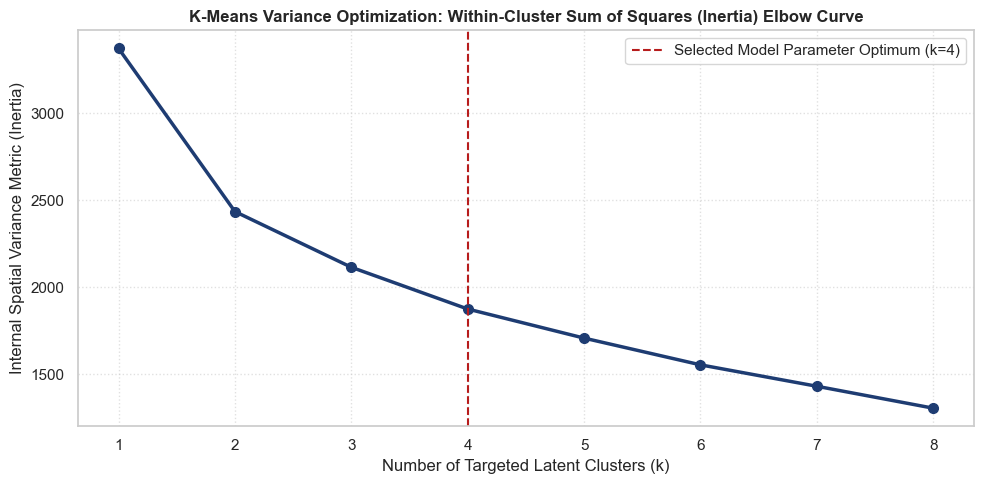

In [11]:
elbow_records = []

for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_df)
    elbow_records.append({"k": k, "Inertia": km.inertia_})

elbow_df = pd.DataFrame(elbow_records)

plt.figure(figsize=(10, 5))
plt.plot(elbow_df['k'], elbow_df['Inertia'], marker='o', color='#1e3c72', linewidth=2.5, markersize=7)

plt.axvline(x=4, color='#b71c1c', linestyle='--', linewidth=1.5, label='Selected Model Parameter Optimum (k=4)')

plt.title("K-Means Variance Optimization: Within-Cluster Sum of Squares (Inertia) Elbow Curve", weight='bold')
plt.xlabel("Number of Targeted Latent Clusters (k)")
plt.ylabel("Internal Spatial Variance Metric (Inertia)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()